In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"../data/processed/feature_engineered_data.csv")
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id,...,RollingMean_7,RollingMean_14,RollingMean_30,RollingStd_7,CompetitionAgeMonths,PromoDurationMonths,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos
0,1,3,2013-02-06,6140,693,1,1,0,0,226264,...,5388.428571,5346.071429,5103.833333,1109.382990,53.966667,0.0,0.866025,0.5,0.433884,-0.900969
1,1,4,2013-02-07,5499,675,1,1,0,0,318919,...,5733.428571,5399.357143,5124.166667,851.378658,54.000000,0.0,0.866025,0.5,-0.433884,-0.900969
2,1,5,2013-02-08,5681,630,1,1,0,0,440864,...,5861.714286,5383.571429,5163.233333,707.864797,54.033333,0.0,0.866025,0.5,-0.974928,-0.222521
3,1,6,2013-02-09,5370,656,1,0,0,0,779012,...,6000.571429,5390.928571,5203.066667,512.408319,54.066667,0.0,0.866025,0.5,-0.781831,0.623490
4,1,1,2013-02-11,4409,599,1,0,0,0,179504,...,5963.000000,5403.428571,5215.500000,551.966786,54.133333,0.0,0.866025,0.5,0.781831,0.623490


In [6]:
df["Date"].min(), df["Date"].max()

('2013-01-31', '2015-07-17')

In [7]:
df_model = df.copy()

## Data Splitting

In [8]:
cutoff_date = "2015-06-01"

train_df = df_model[df_model["Date"] < cutoff_date]
test_df  = df_model[df_model["Date"] >= cutoff_date]

In [9]:
X_train = train_df.drop(columns=["Sales", "Date", "Customers"])
y_train = train_df["Sales"]

X_test_date = test_df["Date"]

X_test = test_df.drop(columns=["Sales", "Date", "Customers"])
y_test = test_df["Sales"]

In [10]:
print(X_train.shape)
print(X_test.shape)

(752277, 40)
(45191, 40)


## Base Model

In [11]:
from sklearn.linear_model import LinearRegression
import time

baseline_model = LinearRegression()
start = time.time()
baseline_model.fit(X_train, y_train)
baseline_train_time = time.time() - start

In [12]:
baseline_pred = baseline_model.predict(X_test)
print(baseline_pred[:5])

[7634.15059798 5825.15375122 5320.72712524 5929.5241147  3702.39603201]


In [13]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, baseline_pred)
rmse = root_mean_squared_error(
    y_test,
    baseline_pred
)
r2 = r2_score(y_test, baseline_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 858.50
RMSE: 1214.24
R²  : 0.8511


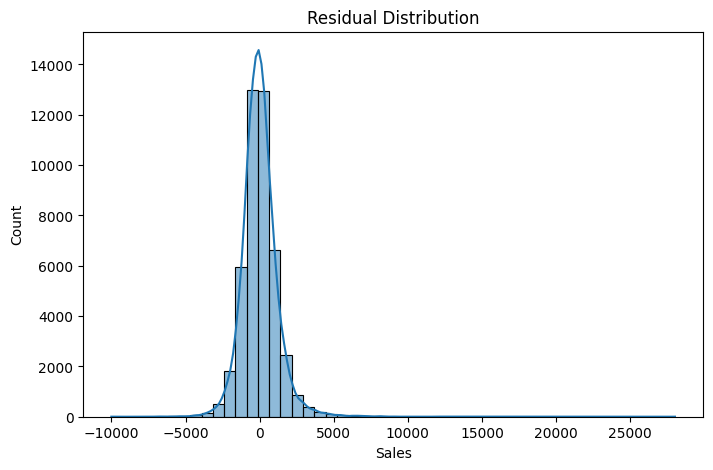

In [14]:
residuals = y_test - baseline_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

In [15]:
coef = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": baseline_model.coef_
})

coef.sort_values(
    by="Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient
3,Promo,1770.244990
25,IsMonthEnd,1108.423555
24,IsMonthStart,684.958018
39,DayOfWeek_cos,599.150969
36,Month_sin,543.597533
5,SchoolHoliday,248.777137
12,Promo2,162.551847
19,Week,29.347288
22,WeekOfYear,29.347288
21,DayOfYear,14.037709


## Some of Advanced Model

In [16]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import time

In [17]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    return mae, rmse, r2, train_time, pred

In [18]:
dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

dt_mae, dt_rmse, dt_r2, dt_time, dt_pred = evaluate_model(
    dt,
    X_train,
    y_train,
    X_test,
    y_test
)

In [19]:
rf = RandomForestRegressor(
    n_estimators=5,
    random_state=42,
    n_jobs=-1
)

rf_mae, rf_rmse, rf_r2, rf_time, rf_pred = evaluate_model(
    rf,
    X_train,
    y_train,
    X_test,
    y_test
)

In [20]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)
xgb_mae, xgb_rmse, xgb_r2, xgb_time, xgb_pred = evaluate_model(
    xgb,
    X_train,
    y_train,
    X_test,
    y_test
)

## Model Evaluation and Comparison

In [21]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "MAE":[
        mae,
        dt_mae,
        rf_mae,
        xgb_mae
    ],

    "RMSE":[
        rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "R2":[
        r2,
        dt_r2,
        rf_r2,
        xgb_r2
    ],

    "Training Time":[
        baseline_train_time,
        dt_time,
        rf_time,
        xgb_time
    ]

})

results.sort_values("RMSE")

,Model,MAE,RMSE,R2,Training Time
3,XGBoost,629.672852,882.961914,0.921261,48.804773
2,Random Forest,712.188883,1017.902398,0.895356,89.427462
1,Decision Tree,775.228284,1112.037381,0.875106,18.412953
0,Linear Regression,858.495894,1214.240727,0.851094,4.699810


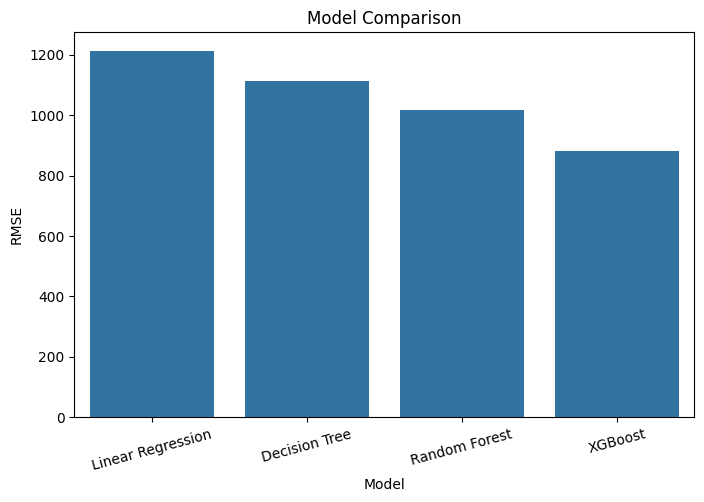

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)

plt.xticks(rotation=15)

plt.title("Model Comparison")

plt.show()

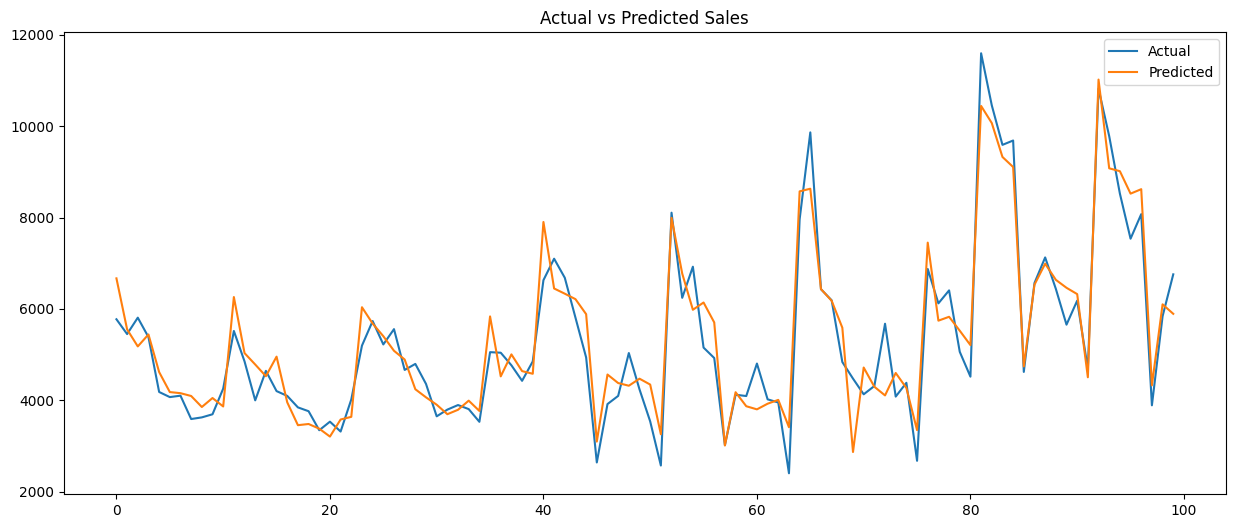

In [23]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.values[:100],
    label="Actual"
)

plt.plot(
    xgb_pred[:100],
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted Sales")

plt.show()

In [24]:
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":xgb.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

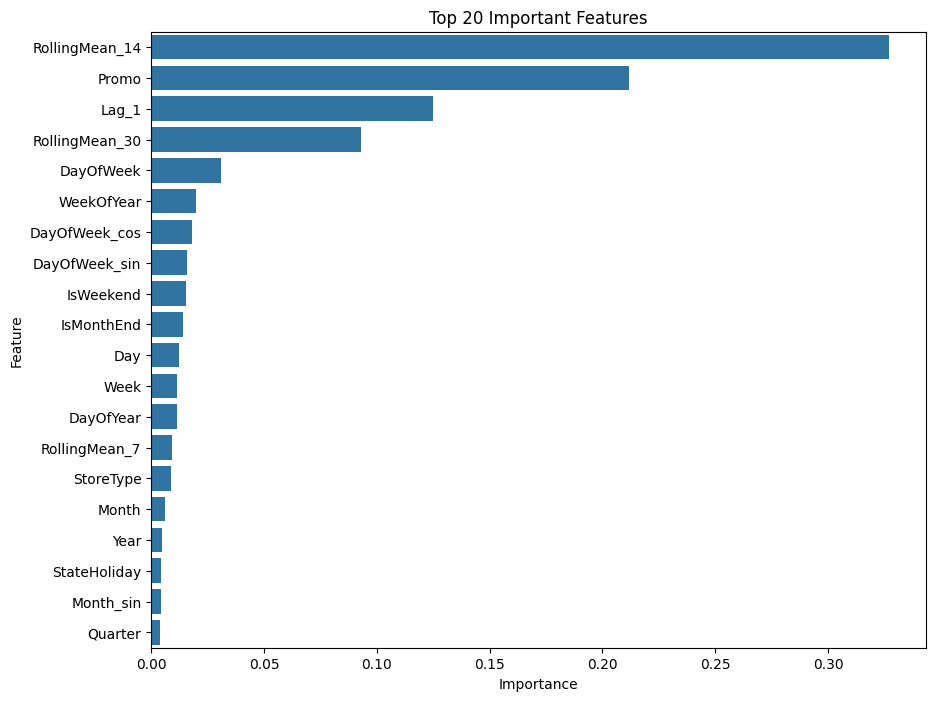

In [25]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature"

)

plt.title("Top 20 Important Features")

plt.show()

## Model Tunning

In [26]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
param_grid = {

    "n_estimators":[200,300,500,700],

    "max_depth":[4,6,8,10],

    "learning_rate":[0.01,0.03,0.05,0.1],

    "subsample":[0.7,0.8,0.9,1.0],

    "colsample_bytree":[0.7,0.8,0.9,1.0],

    "min_child_weight":[1,3,5],

    "gamma":[0,0.1,0.2,0.3]

}

In [27]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

In [28]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=1,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [29]:
random_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 1 candidates, totalling 3 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [4, 6, ...], ...}"
,n_iter,1
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [30]:
random_search.best_params_

{'subsample': 0.9,
 'n_estimators': 300,
 'min_child_weight': 3,
 'max_depth': 10,
 'learning_rate': 0.03,
 'gamma': 0.1,
 'colsample_bytree': 0.9}

In [31]:
best_xgb = random_search.best_estimator_

In [32]:
best_pred = best_xgb.predict(X_test)

In [43]:
mae = mean_absolute_error(y_test,best_pred)

rmse = root_mean_squared_error(y_test,best_pred)

r2 = r2_score(y_test,best_pred)

In [44]:
comparison = pd.DataFrame({

    "Model":[
        "Original XGBoost",
        "Tuned XGBoost"
    ],
    "MAE":[
        xgb_mae,
        mae
    ],
    "RMSE":[
        xgb_rmse,
        rmse
    ],
    "R2":[
        xgb_r2,
        r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Original XGBoost,629.672852,882.961914,0.921261
1,Tuned XGBoost,627.676208,886.016541,0.920716


## Explainability

In [45]:
import shap

In [46]:
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test.sample(100, random_state=42))

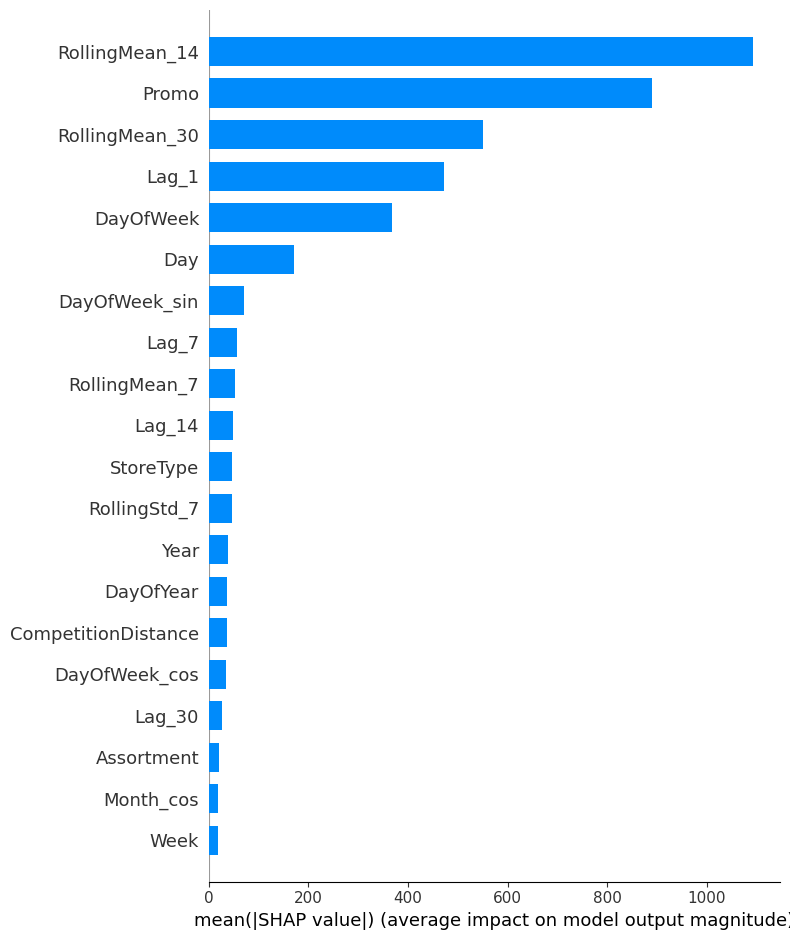

In [47]:
shap.summary_plot(
    shap_values,
    X_test.sample(100, random_state=42),
    plot_type="bar"
)

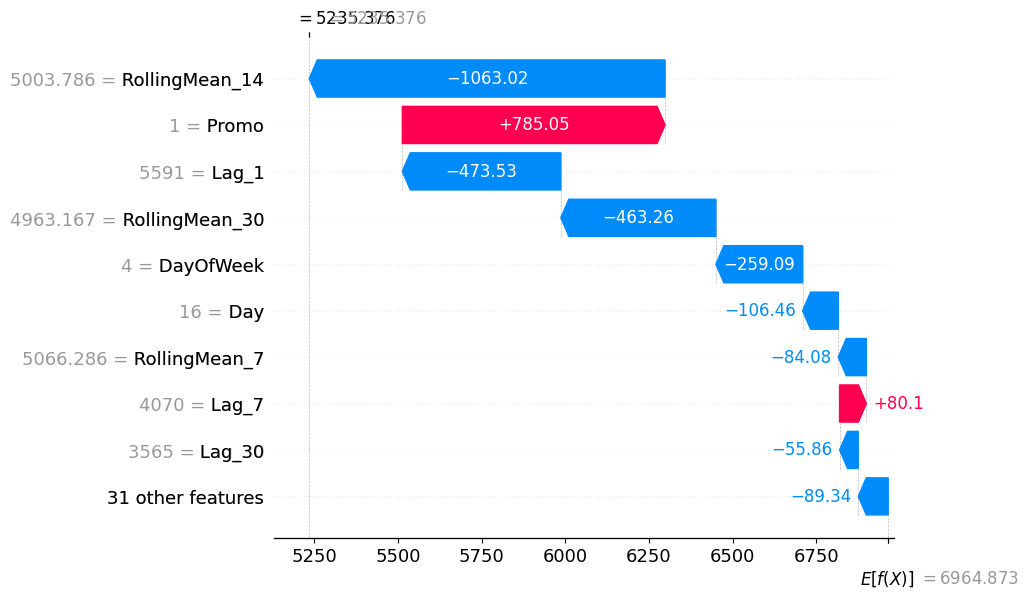

In [48]:
shap.plots.waterfall(shap_values[10])

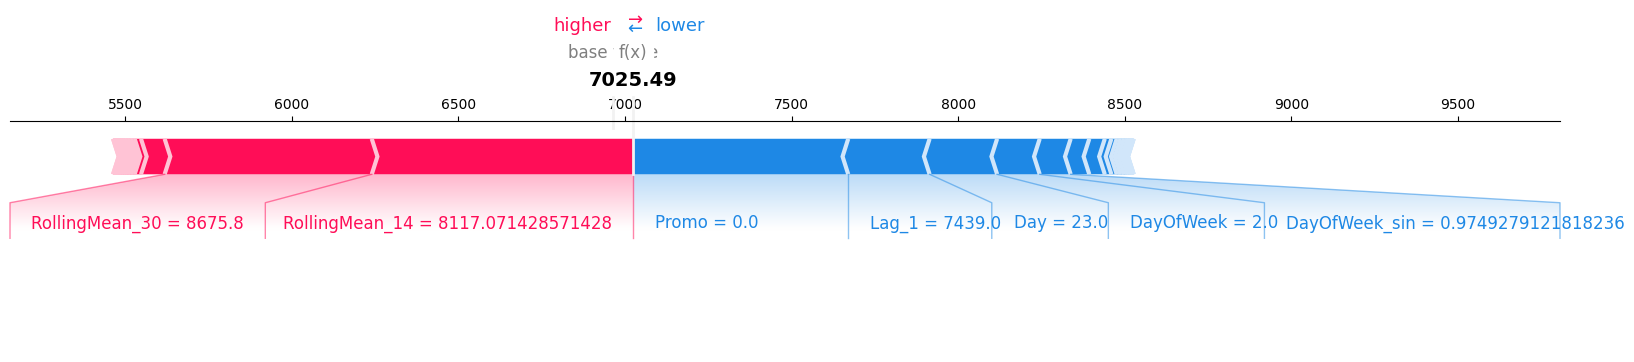

In [49]:
shap.plots.force(
    shap_values[0],
    matplotlib=True
)

In [50]:
importance.head(20).to_csv(
    "../reports/feature_importance.csv",
    index=False
)

In [51]:
import joblib

joblib.dump(
    xgb,
    "../models/xgboost_sales_forecast.pkl"
)

['../models/xgboost_sales_forecast.pkl']

In [52]:
prediction_df = pd.DataFrame({

    "Date": X_test_date,

    "Actual":y_test,

    "Predicted":xgb_pred

})

prediction_df.to_csv(
    "../reports/predictions.csv",
    index=False
)

## Interpretation

Feature insights:
- `RollingMean_14` is the most important predictor, showing that recent two-week sales momentum is the key driver.
- `Promo` and `Lag_1` are also highly important, indicating that current promotions and yesterday’s sales strongly influence predictions.
- `RollingMean_30` and weekday/seasonal features contribute meaningfully, while competition-related variables are less influential.

SHAP interpretation:
- Recent sales history drives the largest positive and negative contributions to predictions.
- Promotional activity consistently boosts forecasted sales.
- Seasonal and store-specific patterns matter, especially day-of-week and month effects.
- Competition features have a smaller impact compared to the store’s own recent demand patterns.

Business takeaway:
- Forecasting should prioritize recent sales trends and promotional schedules.
- Planning should focus on maintaining stock and staffing around strong recent momentum and promotional periods.
- Competition is a factor, but internal sales history and promotions are the primary levers for accurate forecasting.